## Frequential analysis of events

In [1]:
from pyspark.sql import functions as F
from utils.ml import data_dir, spark, fit_zipfs
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/20 08:09:06 WARN Utils: Your hostname, DESKTOP-UQF5BSK, resolves to a loopback address: 127.0.1.1; using 172.24.225.163 instead (on interface eth0)
26/04/20 08:09:06 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/20 08:09:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
df = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df.show(5)

+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|year|month|day|order|country|session ID|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|
+----+-----+---+-----+-------+----------+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+
|2008|    4|  1|    1|     29|         1|                     1|                    A13|     1|       5|                1|   28|      2|   1|
|2008|    4|  1|    2|     29|         1|                     1|                    A16|     1|       6|                1|   33|      2|   1|
|2008|    4|  1|    3|     29|         1|                     2|                     B4|    10|       2|                1|   52|      1|   1|
|2008|    4|  1|    4|     29|         1|                     2|                    B17|     6|       6|                2|   38|      2|   1|
|2008|

## Constructing tokens

Token information is everything except "year", "month", "day", "session ID", "order", and for now we will ignore the country

In [3]:
to_omit = ["year", "month", "day", "session ID", "order", "country"]
token_cols = [col for col in df.columns if col not in to_omit]
print(token_cols)

['page 1 (main category)', 'page 2 (clothing model)', 'colour', 'location', 'model photography', 'price', 'price 2', 'page']


In [4]:
tokens = df.select(*token_cols).drop_duplicates()
print("Total amount of unique tokens: ", tokens.count())

Total amount of unique tokens:  218


### Index tokens and join index

In [5]:
tokens = tokens.withColumn("id", F.monotonically_increasing_id())
df = df.join(tokens, on = token_cols, how="left")
df.show(5)

+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+----+-----+---+-----+-------+----------+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page|year|month|day|order|country|session ID| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+----+-----+---+-----+-------+----------+---+
|                     1|                    A13|     1|       5|                1|   28|      2|   1|2008|    4|  1|    1|     29|         1|197|
|                     1|                    A16|     1|       6|                1|   33|      2|   1|2008|    4|  1|    2|     29|         1|149|
|                     2|                     B4|    10|       2|                1|   52|      1|   1|2008|    4|  1|    3|     29|         1| 51|
|                     2|                    B17|     6|       6|                2|   38|      2|   1|2008|    4|  1|    4|  

### Get frequencies

In [6]:
freq = df.groupBy("id").count()
print("Sum verification: ", freq.select(F.sum(freq["count"])).collect()[0][0])

Sum verification:  165474


### Zipf's fitting and Plotting

Ignored 0 top and 10 bottom tokens for estimation and fitting


26/04/20 08:09:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/20 08:09:36 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


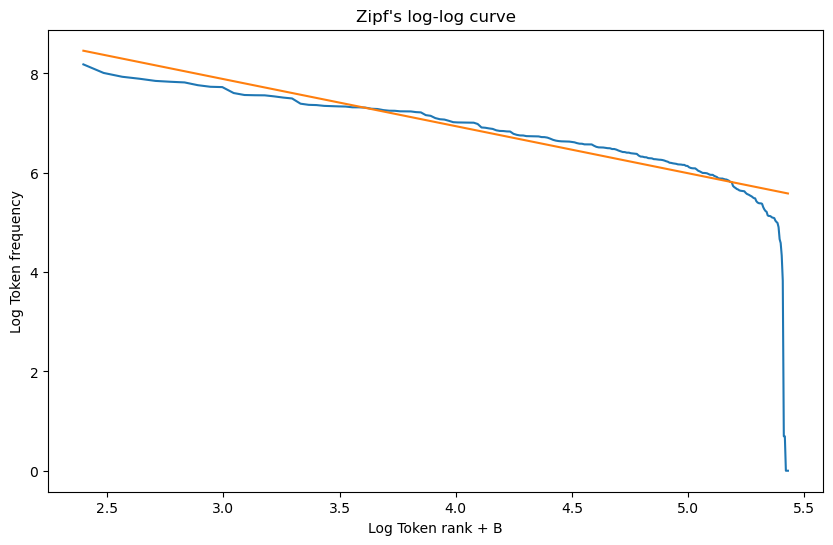

Zipf's fit R-squared:  0.9230596509189264
Zipf's fit MSE:  0.0382498080805847
Zipf's fit Explained Variance:  0.4588860580275158
C estimate: 45791.55
Alpha estimate: 0.95


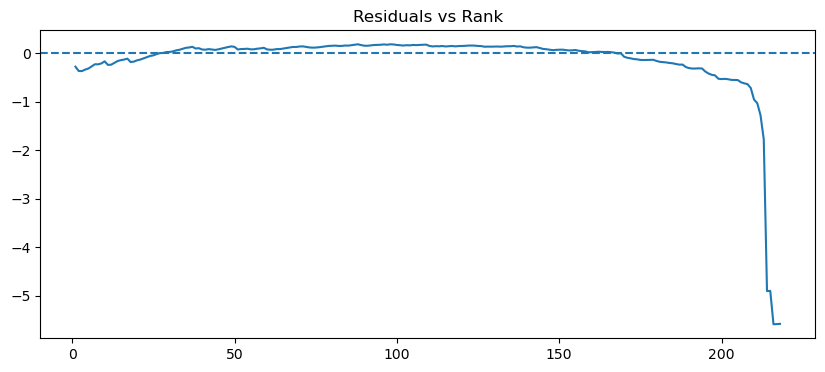

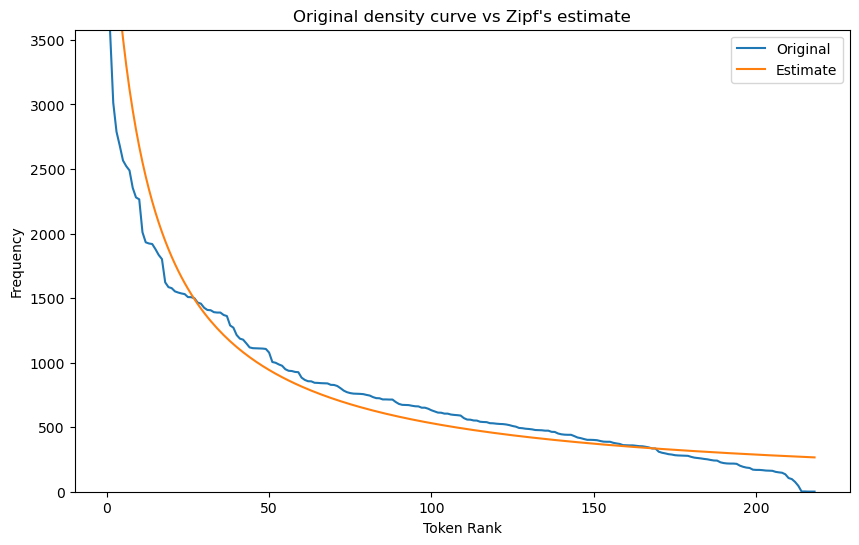

In [7]:
freqz, freqz_pd = fit_zipfs(freq, ignore_bottom=10)

Adjust above - ignore bottom or top to change the basis for fitting evaluation

### Top and worst products

In [8]:
freqz = freqz.join(tokens.select("id","page 2 (clothing model)"), on = "id", how = "left")
top_10_products = freqz.where(F.col("rank") <= 10)
worst_10_products = freqz.where(F.col("rank") >= (freqz.count() - 10))
print("TOP:")
top_10_products.show()
print("BOTTOM:")
worst_10_products.show()

TOP:


+---+----+------------------+------------------+-----+------------------+------------------+-----------------------+
| id|rank|         log_ranks|         log_freqs|count|          estimate|      density_pred|page 2 (clothing model)|
+---+----+------------------+------------------+-----+------------------+------------------+-----------------------+
| 51|   1|2.3978952727983707| 8.182838710766026| 3579| 8.458026266403298|  4712.74710475251|                     B4|
|212|   2|2.4849066497880004|   8.0106915391303| 3013|  8.37551684340308| 4339.510546381164|                     A2|
| 62|   3|2.5649493574615367| 7.933438387627489| 2789|  8.29961553194233| 4022.325640776367|                    A11|
| 86|   4|2.6390573296152584| 7.893945138235959| 2681| 8.229341893785234|3749.3654592695657|                     P1|
| 76|   5|  2.70805020110221| 7.850103545175582| 2566| 8.163918701847988|3511.9218486601007|                    B10|
|191|   6| 2.772588722239781|7.8328075165248645| 2522| 8.1027193

### Cumulative contribution of events (products) to total click count

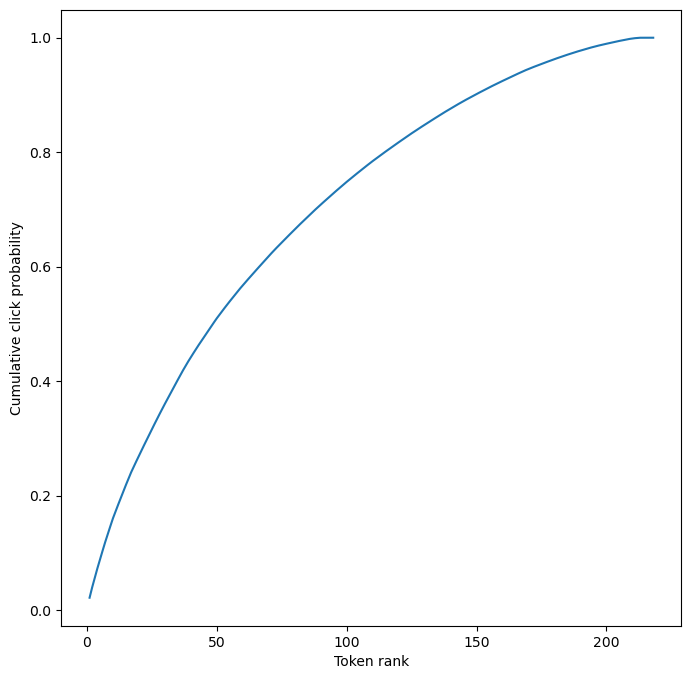

Tokens(products) contributing to 50% of clicks:  48


In [9]:
freqz_pd["norm_sum"] = ((freqz_pd["count"] / freqz_pd["count"].sum())).cumsum()
plt.figure(figsize=(8, 8))
plt.plot(freqz_pd["rank"], freqz_pd["norm_sum"])
plt.xlabel("Token rank") #here can be interpreted as count
plt.ylabel("Cumulative click probability")
plt.show()
print("Tokens(products) contributing to 50% of clicks: ", sum(freqz_pd["norm_sum"] <= 0.5))

## Brief Session length analysis

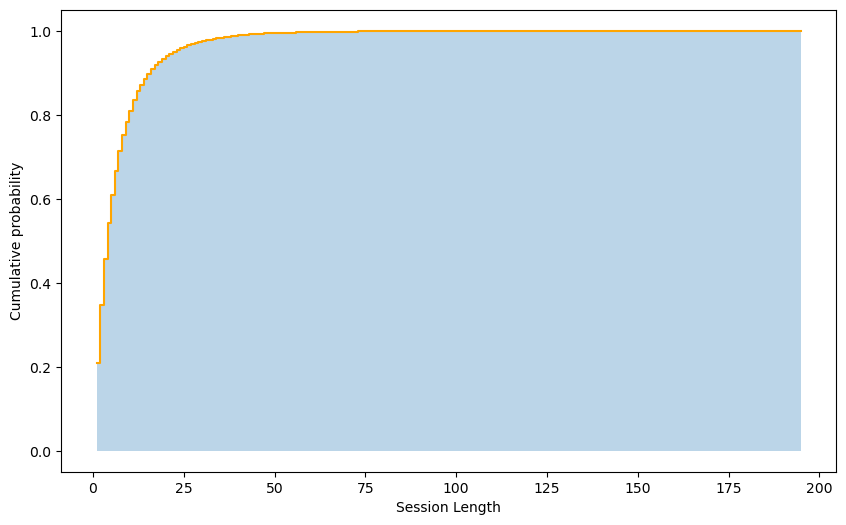

In [10]:
from pyspark.sql import Window
session_lengths = df.groupBy("Session ID").count().withColumnRenamed("count", "length").groupBy("length").count().orderBy("count")
session_lengths = session_lengths.withColumn("probability", F.col("count") / session_lengths.agg(F.sum("count")).collect()[0][0])
pdf = session_lengths.orderBy("length").toPandas()
#w = Window.orderBy(F.asc("length")).rowsBetween(Window.unboundedPreceding, Window.currentRow) #cumulative sum operator
#session_lengths = session_lengths.withColumn("cum_probability", F.sum("probability").over(w))
pdf["cum_probability"] = pdf["probability"].cumsum()
plt.figure(figsize=(10, 6))
sns.lineplot(pdf, x = "length", y = "cum_probability", drawstyle="steps-post", color = "orange")
plt.fill_between(pdf["length"],pdf["cum_probability"], step="post", alpha=0.3)
plt.xlabel("Session Length")
plt.ylabel("Cumulative probability")
plt.show()